# Scene Segmenter Training

Thin orchestrator notebook. Heavy lifting lives in `src/train_segmenter/`.

The configuration cell builds a `SegmenterPipelineConfig`. Everything else is a
single function call into the package, so reruns are cheap and deterministic.

In [ ]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd() / "project" / "notebooks" / "do" / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.train_segmenter import (
    SegmenterPipelineConfig,
    initialize_segmenter_pipeline,
    plot_segmentation_predictions,
    plot_training_curves,
    run_segmenter_training,
)

# Most-used quick knobs
SEED = 42
IMAGE_SIZE = 256
VAL_SPLIT = 0.20
MAX_SCENE_PAIRS = None  # Cap total augmented scenes before train/val split
EPOCH_MAX_TRAIN_SAMPLES = 500  # Cap train samples seen per epoch

CACHE_IN_RAM = True
NUM_WORKERS = 4

EPOCHS = 30
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
USE_AMP = True
USE_TORCH_COMPILE = False
EARLY_STOPPING_PATIENCE = 8
LOG_EVERY_BATCHES = 25

BCE_LOSS_WEIGHT = 0.5
DICE_LOSS_WEIGHT = 0.5
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

WARM_START = False
WARM_START_FILENAME = "segmenter_unet_small.pth"
CHECKPOINT_FILENAME = "scene_segmenter_unet_small.pth"
PREVIEW_COUNT = 6

DATA_CFG = dict(
    seed=SEED,
    image_size=IMAGE_SIZE,
    val_split=VAL_SPLIT,
    max_scene_pairs=MAX_SCENE_PAIRS,
    epoch_max_train_samples=EPOCH_MAX_TRAIN_SAMPLES,
    cache_in_ram=CACHE_IN_RAM,
    num_workers=NUM_WORKERS,
 )

TRAIN_CFG = dict(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    use_amp=USE_AMP,
    use_torch_compile=USE_TORCH_COMPILE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    log_every_batches=LOG_EVERY_BATCHES,
    train_loss_bce_weight=BCE_LOSS_WEIGHT,
    train_loss_dice_weight=DICE_LOSS_WEIGHT,
    scheduler_factor=SCHEDULER_FACTOR,
    scheduler_patience=SCHEDULER_PATIENCE,
    warm_start=WARM_START,
    warm_start_filename=WARM_START_FILENAME,
    checkpoint_filename=CHECKPOINT_FILENAME,
    preview_count=PREVIEW_COUNT,
 )

CFG = SegmenterPipelineConfig(**DATA_CFG, **TRAIN_CFG)
CFG

## Initialize the pipeline

Builds the train/val pair lists, datasets and loaders, instantiates
`SceneUNetSmall`, the optimizer, scheduler and AMP scaler. Honors
`max_scene_pairs` and `epoch_max_train_samples` from the config. Asserts the
param cap (R1) and that no training input lives under a `test` directory (R3).

In [ ]:
state = initialize_segmenter_pipeline(CFG)
state.keys()

## Train

Runs the BCE+Dice loop with verbose batch logging, saves the best checkpoint
on val IoU, and supports early stopping.

In [3]:
state = run_segmenter_training(state)
{
    "best_val_iou": state.get("best_val_iou"),
    "best_epoch": state.get("best_epoch"),
    "training_seconds": state.get("training_seconds"),
}

  summary | train_loss=0.0228 val_loss=0.0210 | train_iou=0.9409 val_iou=0.9456 | lr=1.00e-03
  times   | train=00:41 val=00:20 epoch=01:02 | speed=11.9 img/s | gpu_mem=0.00 GB | eta=14:18 | best checkpoint saved

[Epoch 17/30] starting...
    batch 001/125 | avg_loss=0.0166 avg_iou=0.9594 | eta=00:53
    batch 025/125 | avg_loss=0.0209 avg_iou=0.9450 | eta=00:34
    batch 050/125 | avg_loss=0.0210 avg_iou=0.9452 | eta=00:25
    batch 075/125 | avg_loss=0.0212 avg_iou=0.9448 | eta=00:17
    batch 100/125 | avg_loss=0.0212 avg_iou=0.9446 | eta=00:08
    batch 125/125 | avg_loss=0.0211 avg_iou=0.9451 | eta=00:00
  summary | train_loss=0.0211 val_loss=0.0207 | train_iou=0.9451 val_iou=0.9460 | lr=1.00e-03
  times   | train=00:42 val=00:19 epoch=01:02 | speed=11.7 img/s | gpu_mem=0.00 GB | eta=13:20 | best checkpoint saved

[Epoch 18/30] starting...
    batch 001/125 | avg_loss=0.0219 avg_iou=0.9444 | eta=00:53
    batch 025/125 | avg_loss=0.0208 avg_iou=0.9459 | eta=00:34
    batch 050/12

{'best_val_iou': 0.9594051292538643,
 'best_epoch': 30,
 'training_seconds': 1865.2008085000052}

## Training diagnostics

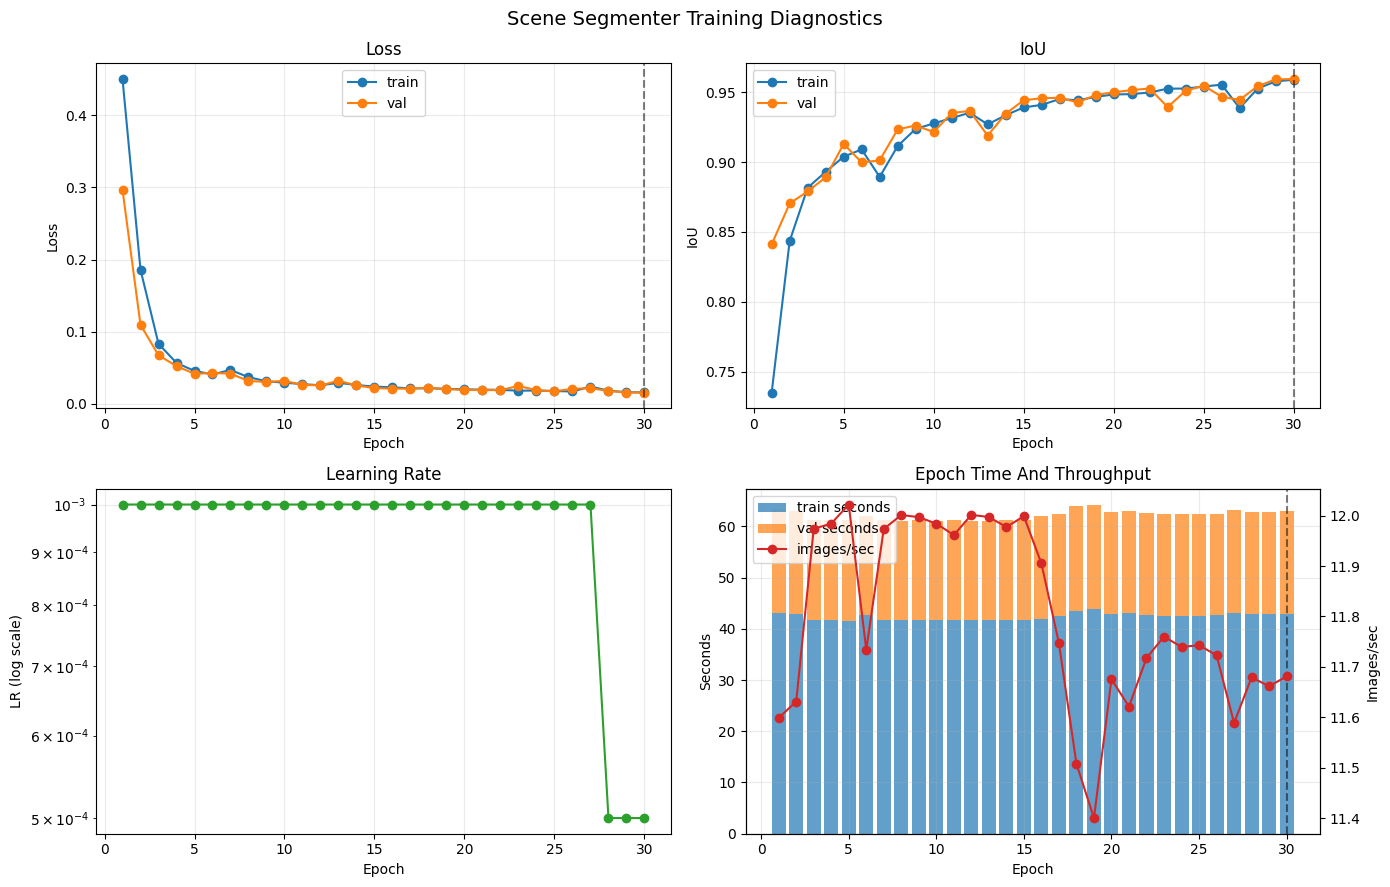

Best epoch: 30
Best val IoU: 0.9594
Epoch time at best epoch: 63.03s
Mean throughput: 11.80 img/s


In [4]:
plot_training_curves(state)

## Qualitative predictions on validation

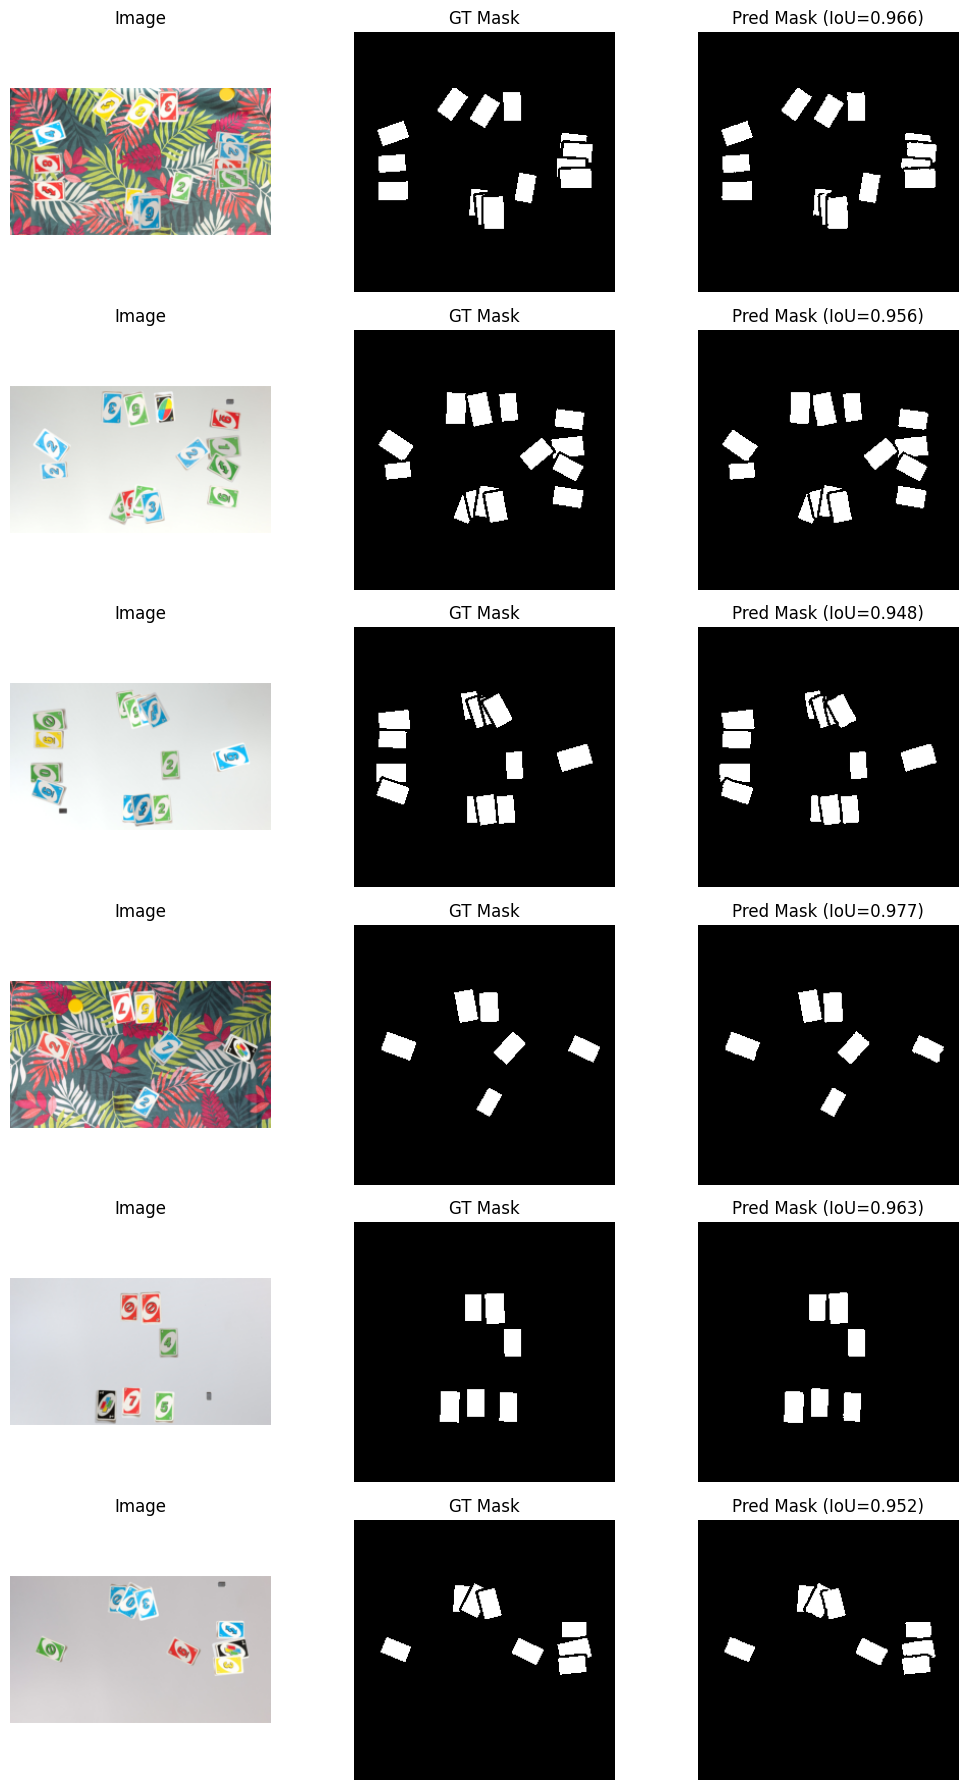

In [5]:
plot_segmentation_predictions(state, num_show=CFG.preview_count)